In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

In [2]:
# Load e-commerce transaction datasets
df1 = pd.read_csv('ecommerce_customer_data_large.csv')
df2 = pd.read_csv('ecommerce_customer_data_custom_ratios.csv')

In [3]:
# Inspect column names to confirm consistency
df1.columns
df2.columns

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='object')

In [4]:
# Data structure check
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202618 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


In [5]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202404 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


In [6]:
# Check missing values
df1.isnull().sum()

Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47382
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64

In [7]:
df2.isnull().sum()

Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47596
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64

Two versions of the dataset were provided. After sorting and validating records by Customer ID, both datasets were found to contain identical transactional data. Differences were limited to the ‘Returns’ column, likely due to alternative return assumptions. To avoid duplication and maintain consistency, a single dataset was selected for analysis

In [8]:
df = df1.copy()

In [9]:
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0


In [10]:
# descriptive statistics for numeric columns
df.describe()

,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,202618.000000,250000.000000,250000.00000
mean,25017.632092,254.742724,3.004936,2725.385196,43.798276,0.500824,43.798276,0.20052
std,14412.515718,141.738104,1.414737,1442.576095,15.364915,0.500001,15.364915,0.40039
min,1.000000,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.00000
25%,12590.000000,132.000000,2.000000,1476.000000,30.000000,0.000000,30.000000,0.00000
50%,25011.000000,255.000000,3.000000,2725.000000,44.000000,1.000000,44.000000,0.00000
75%,37441.250000,377.000000,4.000000,3975.000000,57.000000,1.000000,57.000000,0.00000
max,50000.000000,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.00000


In [11]:
# Convert purchase date to datetime
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

In [12]:
# Standardize column names for consistency and easier querying
df.columns = (df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_"))

In [13]:
# Calculate percentage of missing values per column
df.isna().mean() * 100

customer_id               0.0000
purchase_date             0.0000
product_category          0.0000
product_price             0.0000
quantity                  0.0000
total_purchase_amount     0.0000
payment_method            0.0000
customer_age              0.0000
returns                  18.9528
customer_name             0.0000
age                       0.0000
gender                    0.0000
churn                     0.0000
dtype: float64

In [14]:
# Treat missing returns as no return (0)
df['returns'] = df['returns'].fillna(0)

In [15]:
# Define revenue
df['revenue'] = df['total_purchase_amount']

In [16]:
# Create order counter for aggregation
df['order'] = 1

In [17]:
# Aggregate transaction data to customer-level metrics
customer_df = df.groupby('customer_id').agg(
    total_revenue=('revenue', 'sum'),
    total_orders=('order', 'sum'),
    total_returns=('returns', 'sum'),
    last_purchase_date=('purchase_date', 'max'),
    churn=('churn', 'max'),
    age=('age', 'first'),
    gender=('gender', 'first')
).reset_index()
customer_df.head()

,customer_id,total_revenue,total_orders,total_returns,last_purchase_date,churn,age,gender
0,1,6290,3,0.0,2022-11-29 06:48:25,0,67,Female
1,2,16481,6,4.0,2023-07-03 17:26:19,0,42,Female
2,3,9423,4,0.0,2023-02-03 03:58:07,0,31,Male
3,4,7826,5,3.0,2022-06-29 03:41:09,0,37,Male
4,5,9769,5,3.0,2022-07-16 04:08:09,0,24,Female


RFM analysis (Recency, Frequency, Monetary)

In [18]:
# Define analysis reference date
analysis_date = df['purchase_date'].max()

# Calculate recency in days
customer_df['recency'] = (analysis_date - customer_df['last_purchase_date']).dt.days

# Define frequency and monetary metrics
customer_df['frequency'] = customer_df['total_orders']
customer_df['monetary'] = customer_df['total_revenue']

In [19]:
# Assign RFM quartile scores
customer_df['r_score'] = pd.qcut(customer_df['recency'], 4, labels=[4,3,2,1])
customer_df['f_score'] = pd.qcut(customer_df['frequency'], 4, labels=[1,2,3,4])
customer_df['m_score'] = pd.qcut(customer_df['monetary'], 4, labels=[1,2,3,4])

# Combine RFM scores into a single segment identifier
customer_df['rfm_score'] = (
    customer_df['r_score'].astype(str) +
    customer_df['f_score'].astype(str) +
    customer_df['m_score'].astype(str))

In [20]:
print("\nRFM segmentation sample:")
print(customer_df[['customer_id','r_score','f_score','m_score','rfm_score']].head())


RFM segmentation sample:
   customer_id r_score f_score m_score rfm_score
0            1       2       1       1       211
1            2       4       3       3       433
2            3       2       2       2       222
3            4       1       2       1       121
4            5       1       2       2       122



Total revenue: 681346299

Monthly revenue trend:
purchase_date
2020-01    15566765
2020-02    14660710
2020-03    15517357
2020-04    15060419
2020-05    15517765
2020-06    15062859
2020-07    15575247
2020-08    16190648
2020-09    15134038
2020-10    15758325
2020-11    15281984
2020-12    15551387
2021-01    15415212
2021-02    14310637
2021-03    15386324
2021-04    14955947
2021-05    15597852
2021-06    15103252
2021-07    15811231
2021-08    15914473
2021-09    15174689
2021-10    15514099
2021-11    14725048
2021-12    15763717
2022-01    15470148
2022-02    13983870
2022-03    15720795
2022-04    15266338
2022-05    15737762
2022-06    15295853
2022-07    15997688
2022-08    15304484
2022-09    14876278
2022-10    15322821
2022-11    15597636
2022-12    15771054
2023-01    15749833
2023-02    14095137
2023-03    15731269
2023-04    14934746
2023-05    15680601
2023-06    14824102
2023-07    15203585
2023-08    15654307
2023-09     6578007
Freq: M, Name: revenue, dtype: int64

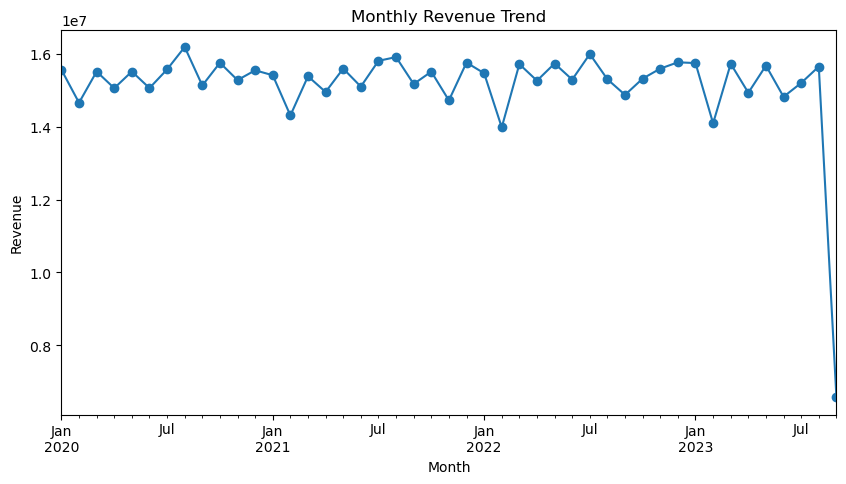


Revenue by product category:
product_category
Books          169345236
Clothing       170716122
Electronics    170146025
Home           171138916
Name: revenue, dtype: int64


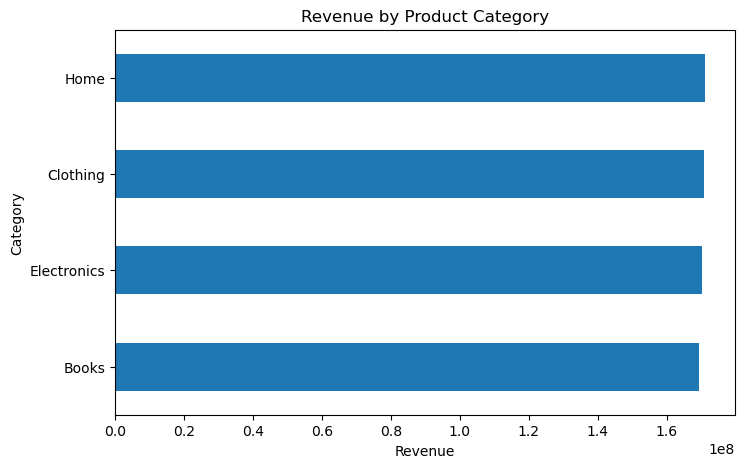

In [21]:
# Revenue & Performance
total_revenue = df['revenue'].sum()
print("\nTotal revenue:", total_revenue)

monthly_revenue = df.groupby(df['purchase_date'].dt.to_period('M'))['revenue'].sum()
print("\nMonthly revenue trend:")
print(monthly_revenue)

# Chart: Monthly revenue trend 
monthly_revenue.plot(kind='line', marker='o', figsize=(10,5)) 
plt.title("Monthly Revenue Trend") 
plt.xlabel("Month") 
plt.ylabel("Revenue") 
plt.show()

category_revenue = df.groupby('product_category')['revenue'].sum()
print("\nRevenue by product category:")
print(category_revenue)

# Chart: Revenue by product category 
category_revenue.sort_values().plot(kind='barh', figsize=(8,5)) 
plt.title("Revenue by Product Category") 
plt.xlabel("Revenue") 
plt.ylabel("Category") 
plt.show()


Top 10 customers by revenue:
       customer_id  total_revenue
39625        39895          50659
39448        39717          50496
48056        48382          50179
6591          6633          48499
49406        49743          47015
22678        22821          46939
24314        24468          46683
13717        13805          46567
537            539          46390
19834        19960          46255

Repeat vs one-time buyers:
total_orders
True     48008
False     1653
Name: count, dtype: int64


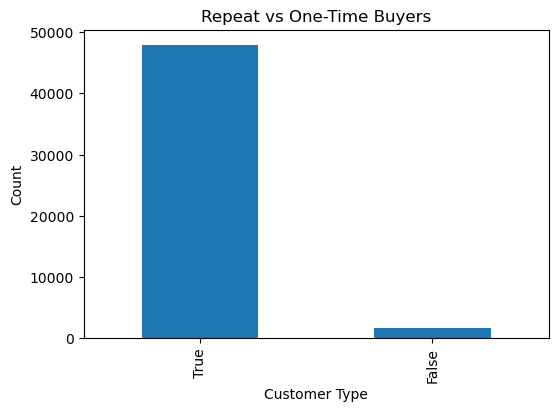


Average order value per customer: 13719.947222166287
Average purchase frequency per customer: 5.034131410966352


In [22]:
# Customer Value & Behavior
top_customers = customer_df.sort_values('total_revenue', ascending=False).head(10)
print("\nTop 10 customers by revenue:") 
print(top_customers[['customer_id','total_revenue']])

repeat_vs_onetime = customer_df['total_orders'].gt(1).value_counts()
print("\nRepeat vs one-time buyers:")
print(repeat_vs_onetime)

# Chart: Repeat vs one-time buyers 
repeat_vs_onetime.plot(kind='bar', figsize=(6,4)) 
plt.title("Repeat vs One-Time Buyers") 
plt.xlabel("Customer Type") 
plt.ylabel("Count") 
plt.show()

avg_order_value = customer_df['total_revenue'].mean()
print("\nAverage order value per customer:", avg_order_value)

purchase_frequency = customer_df['frequency'].mean()
print("Average purchase frequency per customer:", purchase_frequency)

In [23]:
# Customer Segmentation (RFM)
rfm_summary = customer_df.groupby('rfm_score').agg(
    customers=('customer_id','count'),
    revenue=('total_revenue','sum'))

print("\nRFM segment summary:") 
print(rfm_summary)


RFM segment summary:
           customers   revenue
rfm_score                     
111             4866  24372100
112             1208  12389940
113               70    955118
121              686   4900923
122             1910  20929963
123             1483  22175007
124              192   3714840
131               19    149889
132              192   2193659
133              470   7346817
134              360   7298026
141                3     23732
142               39    447852
143              207   3319921
144              693  15940606
211             2122  11920591
212              735   7586424
213               51    697101
221              738   5289381
222             2142  23630058
223             1730  25946328
224              247   4778265
231               28    201781
232              340   3926960
233              916  14281636
234              639  12917936
241                9     71342
242               90   1048264
243              556   8898464
244             2


Average returns by churn status:
churn
0    2.044599
1    2.038473
Name: total_returns, dtype: float64


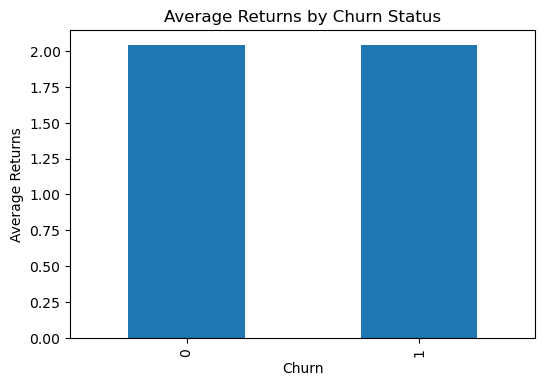


Average returns by product category:
product_category
Books          0.408148
Clothing       0.404308
Electronics    0.406323
Home           0.404848
Name: returns, dtype: float64


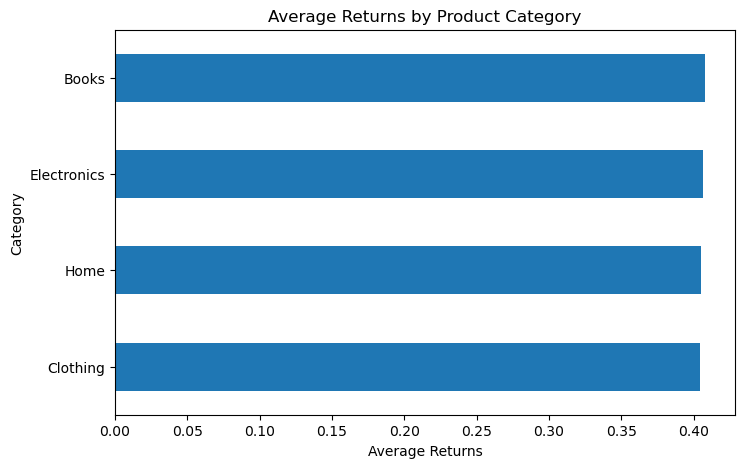


Average returns by payment method:
payment_method
Cash           0.405797
Credit Card    0.405257
PayPal         0.406659
Name: returns, dtype: float64


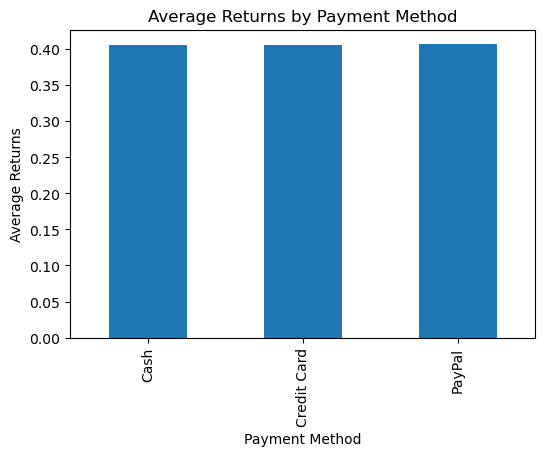

In [24]:
# Returns & Customer Experience
returns_by_churn = customer_df.groupby('churn')['total_returns'].mean()
print("\nAverage returns by churn status:") 
print(returns_by_churn)

# Chart: Returns by churn 
returns_by_churn.plot(kind='bar', figsize=(6,4)) 
plt.title("Average Returns by Churn Status") 
plt.xlabel("Churn") 
plt.ylabel("Average Returns") 
plt.show()

returns_by_category = df.groupby('product_category')['returns'].mean()
print("\nAverage returns by product category:") 
print(returns_by_category)

# Chart: Returns by product category 
returns_by_category.sort_values().plot(kind='barh', figsize=(8,5)) 
plt.title("Average Returns by Product Category") 
plt.xlabel("Average Returns") 
plt.ylabel("Category") 
plt.show()

returns_by_payment = df.groupby('payment_method')['returns'].mean()
print("\nAverage returns by payment method:") 
print(returns_by_payment)

# Chart: Returns by payment method 
returns_by_payment.plot(kind='bar', figsize=(6,4)) 
plt.title("Average Returns by Payment Method") 
plt.xlabel("Payment Method") 
plt.ylabel("Average Returns") 
plt.show()


Churn rate: 0.19993556311793964
Revenue contribution by churn status:
churn
0    544620854
1    136725445
Name: total_revenue, dtype: int64


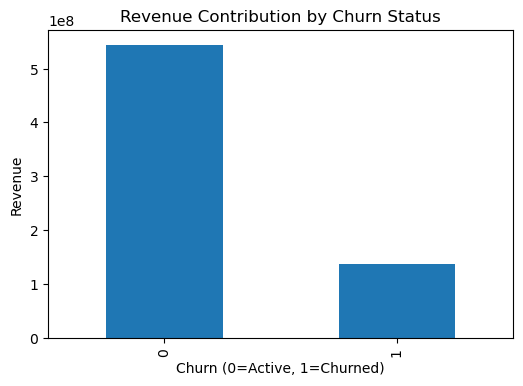


High-value churned customers:
    customer_id  total_revenue
6             7          17825
10           11          17730
14           15          16533
32           33          24987
44           45          23309


In [25]:
# Churn & Retention
churn_rate = customer_df['churn'].mean()
print("\nChurn rate:", churn_rate)

revenue_by_churn = customer_df.groupby('churn')['total_revenue'].sum()
print("Revenue contribution by churn status:") 
print(revenue_by_churn)

# Chart: Revenue by churn status 
revenue_by_churn.plot(kind='bar', figsize=(6,4)) 
plt.title("Revenue Contribution by Churn Status") 
plt.xlabel("Churn (0=Active, 1=Churned)") 
plt.ylabel("Revenue") 
plt.show()

high_value_churners = customer_df[(customer_df['churn']==1) & 
                                  (customer_df['total_revenue'] > customer_df['total_revenue'].median())]
print("\nHigh-value churned customers:") 
print(high_value_churners[['customer_id','total_revenue']].head())

In [26]:
# Compare average customer value by churn status
customer_df.groupby('churn')['monetary'].mean()
customer_df.groupby('churn')['frequency'].mean()

churn
0    5.030454
1    5.048847
Name: frequency, dtype: float64

### Churn vs Customer Value Insight
Average purchase frequency is nearly identical between churned and retained customers. This indicates that churn is not strongly linked to how often customers buy.

In [27]:
# Compare average customer value by churn status
customer_df.groupby('churn')['total_returns'].mean()

churn
0    2.044599
1    2.038473
Name: total_returns, dtype: float64

Average returns are nearly the same for churned and retained customers. This suggests that product returns are not a strong differentiator of churn.

In [28]:
# Identify revenue contribution of top 20% customers
customer_df['revenue_rank'] = customer_df['total_revenue'].rank(pct=True)
top_20_revenue = customer_df[customer_df['revenue_rank'] >= 0.8]['total_revenue'].sum()
total_revenue = customer_df['total_revenue'].sum()

top_20_revenue / total_revenue

np.float64(0.34963698980920127)

Top 20% of customers generate 34% of revenue

In [29]:
# Save
df.to_csv("clean_transactions.csv", index=False)
customer_df.to_csv("customer_level_analysis.csv", index=False)